Expected Annual Return: 0.3752
Portfolio Risk (Std Dev): 0.0187


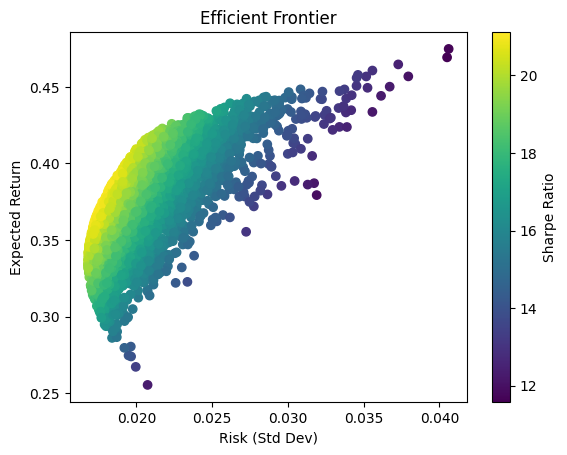

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('portfolio_data.csv')
df.set_index('Date', inplace=True)

# Calculate monthly returns
returns = df.pct_change().dropna()

# Annualized mean returns
mean_returns = returns.mean() * 12

# Covariance matrix
cov_matrix = returns.cov() * 12

# Equal weights portfolio
weights = np.array([0.25, 0.25, 0.25, 0.25])

portfolio_return = np.dot(weights, mean_returns)
portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

print("Expected Annual Return:", round(portfolio_return,4))
print("Portfolio Risk (Std Dev):", round(portfolio_std,4))

# Efficient Frontier Simulation
num_portfolios = 5000
results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(4)
    weights /= np.sum(weights)

    port_return = np.dot(weights, mean_returns)
    port_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    results[0,i] = port_return
    results[1,i] = port_std
    results[2,i] = port_return / port_std  # Sharpe Ratio

plt.figure()
plt.scatter(results[1,:], results[0,:], c=results[2,:])
plt.xlabel("Risk (Std Dev)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")
plt.colorbar(label="Sharpe Ratio")
plt.show()
